# 2.1. Gradient Domain Editing

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Poission Blending
# Mixed Gradient
# Laplacian Pyramid Blending

# Copy-paste

## Config 

In [51]:
scale = 0.4
arg_min_w = 220
arg_min_h = 240
iteration_edges = 3

## Hàm dùng để hiển thị ảnh

In [52]:
def show_plt(title, img):
    plt.title(title)
    plt.axis("off")

    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)

## Load Image

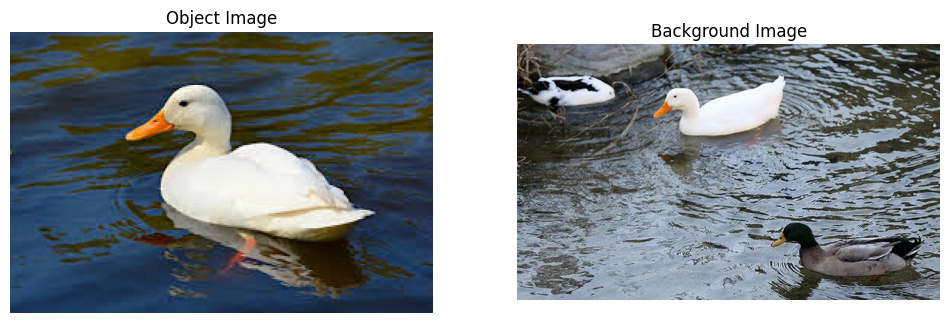

In [53]:
obj_path = "../Images/source1.jpg"
bg_path  = "../Images/background1.jpg"

obj = cv2.imread(obj_path, cv2.IMREAD_COLOR)
bg  = cv2.imread(bg_path, cv2.IMREAD_COLOR)

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
show_plt("Object Image", obj)
plt.subplot(1,2,2)
show_plt("Background Image", bg)

## Tạo mask object

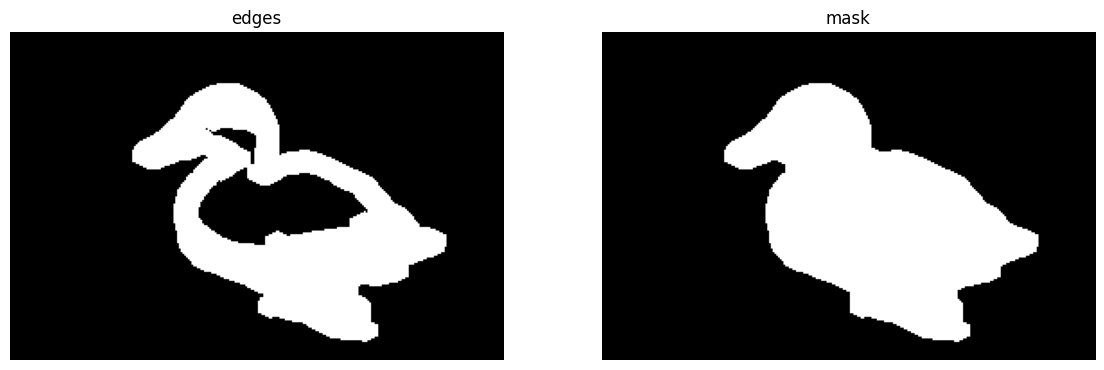

In [54]:
# Chuyển ảnh xám và lọc Gaussian giảm nhiễu
gray = cv2.cvtColor(obj, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5,5), 2)

# Phát hiện biên Canny
edges = cv2.Canny(gray, 50, 150)
# Tạo kernel hình ellipse
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
# Làm dày biên, nối biên đứt
edges = cv2.dilate(edges, kernel, iterations=iteration_edges)

# Tìm các contour ngoài cùng từ ảnh biên
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros(gray.shape, np.uint8)

# Chọn contour có diện tích lớn nhất
cnt = max(contours, key=cv2.contourArea)
cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)

# Đóng vùng mask bằng phép MORPH_CLOSE
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_obj = cv2.bitwise_and(obj, obj, mask=mask)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
show_plt("edges", edges)
plt.subplot(1,2,2)
show_plt("mask", mask)


## Crop mask object

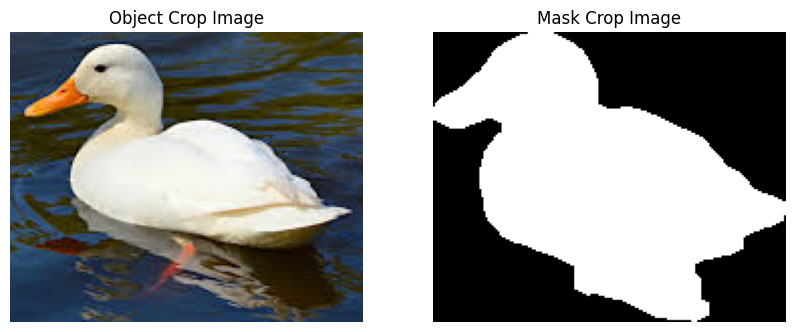

In [55]:
ys, xs = np.where(mask == 255)
y0, y1 = ys.min(), ys.max()
x0, x1 = xs.min(), xs.max()

obj_crop  = obj[y0:y1+1, x0:x1+1]
mask_crop = mask[y0:y1+1, x0:x1+1]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_plt("Object Crop Image", obj_crop)
plt.subplot(1,2,2)
show_plt("Mask Crop Image", mask_crop)

## Resize object

In [56]:
max_h = int(bg.shape[0] * scale)

scale = min(max_h / obj_crop.shape[0], 1.0)

new_w = int(obj_crop.shape[1] * scale)
new_h = int(obj_crop.shape[0] * scale)

obj_crop = cv2.resize(obj_crop, (new_w, new_h))
mask_crop = cv2.resize(mask_crop, (new_w, new_h))

In [57]:
obj_crop.shape

(144, 175, 3)

In [58]:
bg.shape

(369, 609, 3)

## Poisson Blending

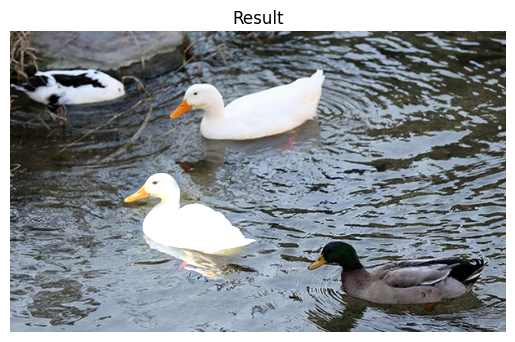

In [59]:
bg_in  = bg.copy()
obj_in = obj_crop.copy()
mask_in = mask_crop.copy()

h, w = obj_in.shape[:2]
cx = max(w//2, min(bg_in.shape[1] - w//2, arg_min_w))
cy = max(h//2, min(bg_in.shape[0] - h//2, arg_min_h))
center = (cx, cy)

result = cv2.seamlessClone(obj_in, bg_in, mask_in, center, cv2.NORMAL_CLONE)
show_plt("Result", result)